<a href="https://colab.research.google.com/github/kondratyukkatya9-ML/ML_home_work/blob/main/Copy_of_HW_2_1_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B2%D1%96%D0%B4_%D0%B1%D0%B0%D0%B3%D0%B0%D1%82%D1%8C%D0%BE%D1%85_%D0%B7%D0%BC%D1%96%D0%BD%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [2]:
!pip install scikit-learn --quiet

In [3]:
from sklearn.linear_model import LinearRegression


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns




# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [5]:
cars_df = pd.read_csv('cars.csv')
cars_df.head()


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [6]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [7]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [8]:
cars_df.dtypes

,0
Car_ID,int64
Brand,object
Model,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,int64
Engine,int64


In [9]:
obj_cols = cars_df.select_dtypes(include='object').columns
cars_df.loc[:, obj_cols].head()

,Brand,Model,Fuel_Type,Transmission,Owner_Type
0,Toyota,Corolla,Petrol,Manual,First
1,Honda,Civic,Petrol,Automatic,Second
2,Ford,Mustang,Petrol,Automatic,First
3,Maruti,Swift,Diesel,Manual,Third
4,Hyundai,Sonata,Diesel,Automatic,Second


In [10]:
cars_df.nunique()


,0
Car_ID,100
Brand,11
Model,58
Year,6
Kilometers_Driven,18
Fuel_Type,2
Transmission,2
Owner_Type,3
Mileage,15
Engine,36


In [11]:
cars_df.select_dtypes(include='object')

,Brand,Model,Fuel_Type,Transmission,Owner_Type
0,Toyota,Corolla,Petrol,Manual,First
1,Honda,Civic,Petrol,Automatic,Second
2,Ford,Mustang,Petrol,Automatic,First
3,Maruti,Swift,Diesel,Manual,Third
4,Hyundai,Sonata,Diesel,Automatic,Second
...,...,...,...,...,...
95,Mercedes,C-Class,Diesel,Automatic,First
96,Toyota,Innova Crysta,Diesel,Manual,Second
97,Ford,EcoSport,Petrol,Manual,Third
98,Hyundai,Verna,Petrol,Automatic,Second


In [12]:
# 2. Виводимо категоріальні (object) колонки — скільки унікальних значень у кожній
cat_cols = cars_df.select_dtypes(include='object')
for col in cat_cols:
    print(f"\n{col} ({cat_cols[col].nunique()} значень):")
    print(cat_cols[col].unique())



Brand (11 значень):
['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']

Model (58 значень):
['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']

Fuel_Type (2 значень):
['Petrol' 'Diesel']

Transmission (2 значень):
['Manual' 'Automatic']

Owner_Type (3 значень):
['First' 'Second' 'Third']


В наборі даних 8 числових і 5 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення): Fuel_Type, Transmission
- 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку: Brand, Model
- 1 колонка, в яких можна встановити відношення порядку Owner_Type

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X = cars_df.drop('Price', axis=1)
y = cars_df['Price']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

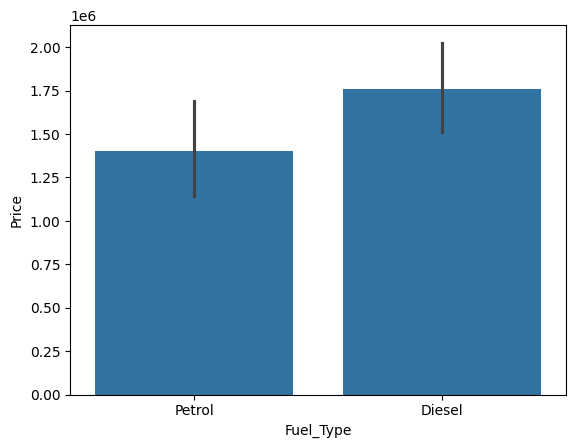

In [16]:
sns.barplot(data=cars_df, x='Fuel_Type', y='Price');

In [17]:
Fuel_Type_codes = {'Petrol': 0, 'Diesel': 1}

In [18]:
X_train['Fuel_Type'] = X_train['Fuel_Type'].map(Fuel_Type_codes)
X_test['Fuel_Type'] = X_test['Fuel_Type'].map(Fuel_Type_codes)



In [19]:
print(X_train['Transmission'].value_counts())

Transmission
Automatic    49
Manual       31
Name: count, dtype: int64


In [20]:
X_train['Transmission'] = X_train['Transmission'].map({'Manual': 0, 'Automatic': 1})
X_test['Transmission'] = X_test['Transmission'].map({'Manual': 0, 'Automatic': 1})

In [21]:
from sklearn.preprocessing import OneHotEncoder


In [22]:
from sklearn import preprocessing


In [23]:
enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])
brand_train = enc.transform(X_train[['Brand']]).toarray()
brand_test = enc.transform(X_test[['Brand']]).toarray()


In [24]:
X_train[enc.categories_[0]] = brand_train
X_test[enc.categories_[0]] = brand_test

In [25]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [26]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,0,1,Second,18,1498,148,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,1,1,First,17,1968,187,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,0,1,First,15,1984,241,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,0,0,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,0,1,Second,12,1991,241,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,0,1,Second,15,1395,148,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,0,0,Third,20,1086,68,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,0,0,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,0,0,First,19,1462,103,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,0,0,Third,20,1194,94,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

In [27]:
print(cars_df['Model'].value_counts())

Model
Mustang          3
C-Class          3
Altroz           3
Verna            3
Passat           2
Thar             2
T-Roc            2
BR-V             2
S-Cross          2
Tigor            2
Santro           2
Ranger           2
Yaris            2
GLE              2
7 Series         2
A3               2
Ameo             2
WR-V             2
Vitara           2
Safari           2
Elantra          2
Aspire           2
Fortuner         2
E-Class          2
X3               2
A6               2
Venue            2
Tiago            2
XUV300           2
Vento            2
Q7               2
X5               2
GLA              2
Camry            2
A5               2
3 Series         2
Innova Crysta    2
EcoSport         2
5 Series         1
GLC              1
Innova           1
Figo             1
Corolla          1
Sonata           1
Swift            1
Civic            1
Ertiga           1
City             1
Tiguan           1
Q3               1
Harrier          1
Creta            1
Endeav

In [28]:
#Створюємо словник, в якому згрупуємо моделі за типом кузова
groups = {
    'SUV': ['Creta', 'Seltos', 'XUV300', 'EcoSport', 'Nexon', 'Harrier', 'Scorpio',
            'Endeavour', 'Fortuner', 'Safari', 'Thar', 'Venue', 'T-Roc', 'Tiguan',
            'Q3', 'Q7', 'X1', 'X3', 'X5', 'GLA', 'GLC', 'GLE', 'WR-V', 'BR-V',
            'Vitara', 'S-Cross'],
    'Sedan': ['City', 'Civic', 'Vento', 'Polo', 'Camry', 'Corolla', 'Sonata', 'Verna',
              'Elantra', 'Passat', 'Ameo', 'Aspire', 'Figo', 'Yaris', 'A3', 'A4', 'A5',
              'A6', '3 Series', '5 Series', '7 Series', 'C-Class', 'E-Class', 'Mustang'],
    'Hatchback': ['Swift', 'Santro', 'Tiago', 'Altroz', 'Tigor'],
    'MPV': ['Ertiga', 'Innova', 'Innova Crysta', 'Ranger'],
}

# Перетворюємо: модель → тип
body_type = {model: typ for typ, models in groups.items() for model in models}

X_train['Body_Type'] = X_train['Model'].map(body_type)
X_test['Body_Type'] = X_test['Model'].map(body_type)

In [29]:
enc_body = preprocessing.OneHotEncoder()
enc_body.fit(X_train[['Body_Type']])
body_train = enc_body.transform(X_train[['Body_Type']]).toarray()
body_test = enc_body.transform(X_test[['Body_Type']]).toarray()
X_train[enc_body.categories_[0]] = body_train
X_test[enc_body.categories_[0]] = body_test

In [30]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Body_Type,Hatchback,MPV,SUV,Sedan
83,84,Volkswagen,T-Roc,2019,22000,0,1,Second,18,1498,148,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,SUV,0.0,0.0,1.0,0.0
55,56,Audi,A5,2018,28000,1,1,First,17,1968,187,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan,0.0,0.0,0.0,1.0
26,27,Audi,A6,2018,28000,0,1,First,15,1984,241,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan,0.0,0.0,0.0,1.0
54,55,Volkswagen,Vento,2017,32000,0,0,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Sedan,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,0,1,Second,12,1991,241,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,SUV,0.0,0.0,1.0,0.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Body_Type,Hatchback,MPV,SUV,Sedan
17,18,Audi,Q3,2016,38000,0,1,Second,15,1395,148,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SUV,0.0,0.0,1.0,0.0
41,42,Hyundai,Santro,2019,26000,0,0,Third,20,1086,68,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Hatchback,1.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,0,0,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Sedan,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,0,0,First,19,1462,103,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,MPV,0.0,1.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,0,0,Third,20,1194,94,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Sedan,0.0,0.0,0.0,1.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [31]:
X_train_num = X_train.select_dtypes(include='number')

In [32]:
X_train_num

,Car_ID,Year,Kilometers_Driven,Fuel_Type,Transmission,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Hatchback,MPV,SUV,Sedan
83,84,2019,22000,0,1,18,1498,148,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
55,56,2018,28000,1,1,17,1968,187,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
26,27,2018,28000,0,1,15,1984,241,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
54,55,2017,32000,0,0,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
19,20,2017,26000,0,1,12,1991,241,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,2020,30000,1,0,23,1248,74,5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0
2,3,2017,20000,0,1,10,4951,395,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,7,2018,45000,1,1,15,2179,140,7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
27,28,2019,22000,1,1,18,1995,187,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [33]:
train_all = pd.concat([X_train_num, y_train], axis=1)


In [34]:
corr = train_all.corr()
corr

,Car_ID,Year,Kilometers_Driven,Fuel_Type,Transmission,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Hatchback,MPV,SUV,Sedan,Price
Car_ID,1.000000,0.137027,-0.356614,-0.090537,-0.084381,0.100891,-0.089284,-0.006319,-0.063793,0.089473,0.048335,-0.020240,-0.050809,0.016831,0.006797,-0.054463,-0.045431,-0.032926,0.011350,0.020129,0.038923,0.083321,0.051435,-0.020088,-0.055931,0.025560
Year,0.137027,1.000000,-0.708525,-0.248515,-0.200603,0.278559,-0.392764,-0.248442,-0.278755,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.014499,0.343705,-0.227726,0.023506,-0.142702,-0.233769
Kilometers_Driven,-0.356614,-0.708525,1.000000,0.332351,-0.066491,-0.126621,0.101219,-0.060803,0.403656,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.001772,-0.108988,0.316181,-0.058048,-0.011927,-0.083951
Fuel_Type,-0.090537,-0.248515,0.332351,1.000000,0.005775,0.070112,0.174455,-0.076357,0.412468,0.008336,0.048475,-0.109812,0.161425,0.007121,0.235225,-0.148511,0.048475,-0.066164,0.008336,-0.125010,-0.281122,-0.109812,0.235225,0.097154,-0.130264,0.110782
Transmission,-0.084381,-0.200603,-0.066491,0.005775,1.000000,-0.399164,0.456296,0.586910,-0.070099,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,0.005886,-0.447620,-0.288430,-0.063196,0.476210,0.680731
Mileage,0.100891,0.278559,-0.126621,0.070112,-0.399164,1.000000,-0.710516,-0.684705,-0.178619,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.026624,0.503799,-0.306880,-0.097244,-0.089889,-0.638404
Engine,-0.089284,-0.392764,0.101219,0.174455,0.456296,-0.710516,1.000000,0.801638,0.167326,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.196106,-0.408034,0.197644,0.084818,0.089211,0.710561
Power,-0.006319,-0.248442,-0.060803,-0.076357,0.586910,-0.684705,0.801638,1.000000,-0.139388,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.204309,-0.388187,-0.006727,0.004900,0.246213,0.849137
Seats,-0.063793,-0.278755,0.403656,0.412468,-0.070099,-0.178619,0.167326,-0.139388,1.000000,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.043849,-0.108079,0.239878,0.328019,-0.363326,0.000979
Audi,0.089473,-0.256523,0.095879,0.008336,0.265132,-0.152701,0.085153,0.157050,0.123674,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.203925,-0.118678,-0.076472,-0.110031,0.219146,0.328858


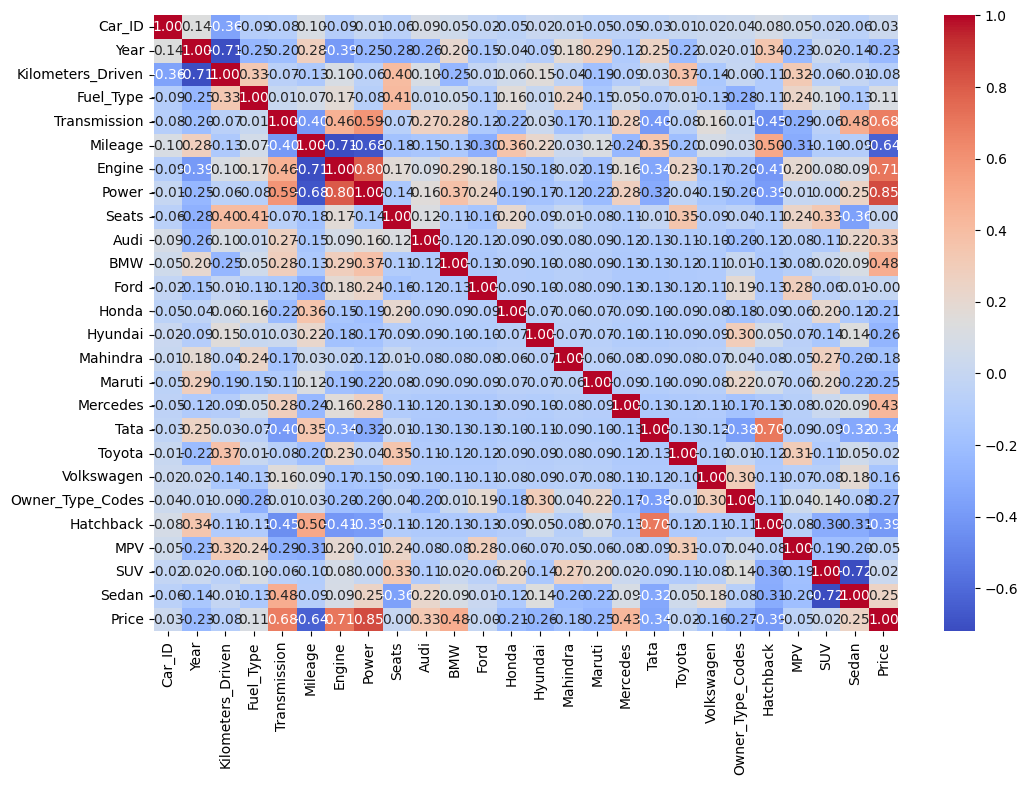

In [35]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [36]:
corr['Price'].sort_values(ascending=False)


,Price
Price,1.000000
Power,0.849137
Engine,0.710561
Transmission,0.680731
BMW,0.477522
Mercedes,0.431606
Audi,0.328858
Sedan,0.252645
Fuel_Type,0.110782
Car_ID,0.025560


Найбільша кореляція з цільовою змінною у колонок: Power, Engine і Transmission. Негативна кореляція - у колонки Mileage. Також між собою обернено корелюють Year та Kilometers_Driven; і пара Mileage - Engine

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [37]:
X_train = X_train.select_dtypes(include='number')
X_test = X_test.select_dtypes(include='number')

In [38]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [39]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f'RMSE train: {rmse_train:.2f}')
print(f'RMSE test: {rmse_test:.2f}')

RMSE train: 198129.48
RMSE test: 283867.25


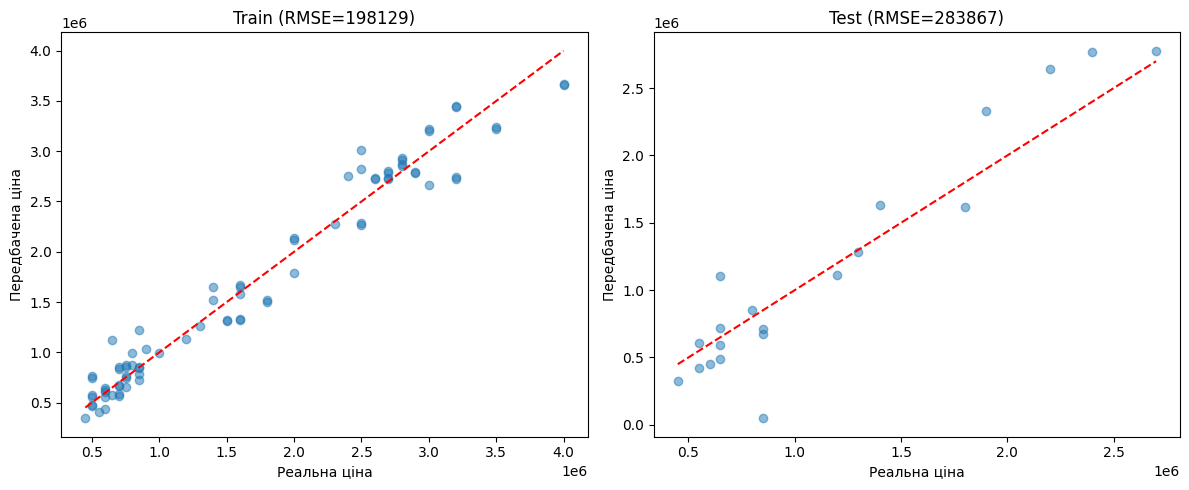

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_train, y_pred_train, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel('Реальна ціна')
axes[0].set_ylabel('Передбачена ціна')
axes[0].set_title(f'Train (RMSE={rmse_train:.0f})')

axes[1].scatter(y_test, y_pred_test, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Реальна ціна')
axes[1].set_ylabel('Передбачена ціна')
axes[1].set_title(f'Test (RMSE={rmse_test:.0f})')

plt.tight_layout()
plt.show()

 RMSE train: 198129.48 нижча за
RMSE test: 283867.25. Модель загалом хороша, хоча на тестових даних показує гірший результат. Це може бути пов'язано як з невеликим обсягом тестової вибірки і більшим розкидом даних у ній, так і з великою кількістю фічей після OneHot кодування відносно кількості спостережень.                 

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [45]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)



LinearRegression()

In [44]:

coefs.sort_values(ascending=False)

,0
Power,459416.284637
BMW,221956.119608
Audi,213594.726583
Mercedes,207737.160167
Fuel_Type,195181.536362
Transmission,124929.099059
Hatchback,57919.522712
Toyota,37788.697000
SUV,34465.472118
Car_ID,11911.457220


Після масштабування ми бачимо, що найбільше впливають коефіцієнти потужності автомобіля, певні марки (BMW,Audi,Mercedes), а також вид пального (Fuel_Type) та коробка передач (Transmission). Оберненопропорційно впливають Mileage, та менш престижні марки. Цілком логічно.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [46]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_scaled)

model_sm = sm.OLS(y_train, X_train_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     63.86
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           4.05e-32
Time:                        14:41:31   Log-Likelihood:                -1089.2
No. Observations:                  80   AIC:                             2226.
Df Residuals:                      56   BIC:                             2284.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.65e+0

Статзначущі коефіцієнти (P-value<0,05): Power, Fuel_Type, Transmission, Mileage,Audi, BMW, Mercedes, Ford, Hyundai, Mahindra, Maruti, Tata, Volkswagen

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [47]:
significant_cols = ['Power', 'Fuel_Type', 'Transmission', 'Mileage',
                    'Audi', 'BMW', 'Mercedes', 'Ford', 'Hyundai',
                    'Mahindra', 'Maruti', 'Tata', 'Volkswagen']

X_train_sig = sm.add_constant(X_train_scaled[significant_cols])
model_sig = sm.OLS(y_train, X_train_sig).fit()
print(model_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     101.3
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           2.53e-38
Time:                        15:13:46   Log-Likelihood:                -1099.7
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      66   BIC:                             2261.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          1.68e+06   2.78e+04     60.421   

R² впав незначно (з 0.963 до 0.952), а Adj. R² майже не змінився (з 0.948 до 0.943). Це означає, що видалені ознаки мало впливали на передбачення.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [48]:
# Ознаки з p-value < 0.25 із Завдання 8
cols_025 = ['Power', 'Fuel_Type', 'Transmission', 'Mileage',
            'Audi', 'BMW', 'Mercedes', 'Ford', 'Hyundai',
            'Mahindra', 'Maruti', 'Tata', 'Volkswagen',
            'Honda', 'Hatchback', 'MPV', 'SUV', 'Sedan']

X_train_025 = sm.add_constant(X_train_scaled[cols_025])
model_025 = sm.OLS(y_train, X_train_025).fit()
print(model_025.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     87.50
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           9.76e-37
Time:                        16:17:38   Log-Likelihood:                -1092.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      62   BIC:                             2264.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          1.68e+06   2.63e+04     63.965   

Модель із Завдання 10 (p < 0.25) має найкращий Adj. R² = 0.949 — навіть трішки вищий, ніж модель з усіма ознаками (0.948), і при цьому використовує на 8 ознак менше. Модель з усіма ознаками — найскладніша, але не найточніша за R². Модель за 13 ознаками найслабша за коефіцієнтами R² та Adj. R². Тому я б обрала модель за всіма ознаками з 8 завдання.